<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/lab4_pe_led.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect. LED VAC measurements


0.1.0

0.2.0 Seven new diodes with measured spectrum

0.2.1 Observed band instead of nominal

0.2.2 Fit by wl low end observed with optical scope - doues not improve

0.2.3 Fit by wl observed with digital scope - does not improve

# Resume

**What we measure.** For each LED we take its current-voltage curve and draw a straight line through the steep upper part (around 0.4-0.9 mA). Where that line crosses zero current, we call $V_0$. So $V_0$ is a turn-on voltage read off the $I\text{–}V$ curve — not the moment the LED actually starts to glow. We did not measure the light itself. Real light appears earlier, where the current is still tiny.

**The slope is close to $h/e$.** Plotting $V_0$ against the LED photon energy gives a straight line with slope within 1-2% of $h/e$. The result agrees with the article [Connor1974](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/Connor1974%20NOTES%20Measuring%20Planck's%20Constant%20Using%20a%20Light%20Emitting.pdf) "NOTES: Measuring Planck's Constant Using a Light Emitting Diode"

**The offset is not zero.** The fitted line does **not** pass through zero — it has an offset of about **−0.3 V**. The simple LED idea $eV_0 = h\nu$ says the line should go through the origin. It doesn't. In fact $V_0$ is **smaller** than the photon energy for *every* LED, by approximately $0.3 \text{V}$.



# LED equation

$$
 h \frac{c}{\lambda} = e V_0
$$

In [53]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request
!wget -q https://raw.githubusercontent.com/tphlabs/data/refs/heads/main/Lab4_SP/spectrumplots.py -O spectrumplots.py -q
from spectrumplots import wavelength_to_color

# Measurements by digital spectroscope

The observed spectrum of the LEDs we used here is shown the [measurements notebook](https://github.com/evgeny-kolonsky/Lab4/blob/main/PE/LED/AVANTES/LEDs_spectrum_measurements.ipynb).



In [61]:
def get_observed_by_nominal(wl):
  data = '''
  # wl_nominal[nm] peak[nm] FWHM[nm]
  390  395 393 13
  400  410 404 12
  420  425 413 16
  500  510 506 28
  520  525 525 30
  540  550 541 34
  560  570 566 41
  730  730 737 34
  '''
  wl_nominal1, wl_nominal2, wl_observed, fwhm = np.genfromtxt(data.splitlines()).T
  err = fwhm / 2
  mask = (wl >= wl_nominal1) & (wl <= wl_nominal2)
  return wl_observed[mask][0], err[mask][0]

# Example
get_observed_by_nominal(420)

(np.float64(413.0), np.float64(8.0))

#Volt-Ampere Curve of LEDs and the Threshold Voltage $V_0$

Looking for the best maximal linear fit starting from the right end.
Section of the linear fi with $I=0$ axis is the treshold voltage $V_0$.

In [69]:
def find_root(V, I, tolerance=0.99):
  ans = np.nan
  left_edges = np.linspace(np.min(V), np.max(V), 50)
  for left in left_edges:
    mask = (V > left)
    fit = linregress(V[mask], I[mask])
    r2 = fit.rvalue**2
    if r2 > tolerance:
      break
  V0 = - fit.intercept / fit.slope
  return V0, fit

#wl V0
395 2.76 393 6
405 2.73 404 6
420 2.70 413 8
500 2.19 506 14
520 2.08 525 15
540 2.01 541 17
560 1.84 566 20
730 1.39 737 17



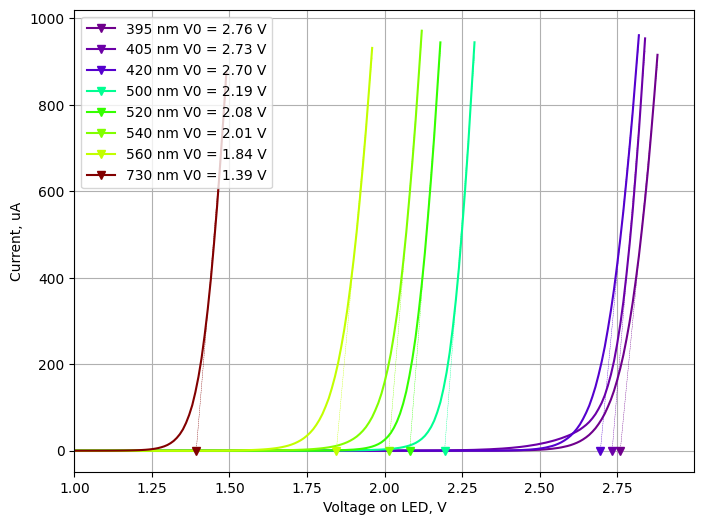

In [71]:
URL = 'https://raw.githubusercontent.com/evgeny-kolonsky/Lab4/refs/heads/main/PE/LED/'
MAX_CURRENT = 0.99e-3 #A

name = 'LED_VAC_7diodes'
url = URL+ f'{name}.csv'
text = request.urlopen(url).read().decode('utf-8').splitlines()
V, I, WL  = np.genfromtxt(text, \
                              delimiter=',', usecols=[1,3,7], skip_header=1, unpack=True)
fig, ax = plt.subplots(figsize=(8,6))
data = '#wl V0\n'
for wl in np.unique(WL):
  mask = (WL == wl) & (I < MAX_CURRENT )
  color = wavelength_to_color(wl)
  plt.plot(V[mask], I[mask]*1e6, color=color)
  V0, fit = find_root(V[mask], I[mask])
  plt.plot(V0, 0, color=color, marker='v', label=f'{wl:.0f} nm V0 = {V0:.2f} V')
  vdense = np.linspace(V0, np.max(V[mask]), 100)
  idense = fit.intercept + fit.slope * vdense
  plt.plot(vdense, idense*1e6, color=color, linestyle='dashed', lw=0.3)
  freq = c/wl *1e9
  wl_observed, wl_observed_err = get_observed_by_nominal(wl)
  data += f'{wl:.0f} {V0:.2f} {wl_observed:.0f} {wl_observed_err:.0f}\n'
  #data += f'{wl:.0f} {V0:.2f}

plt.legend()
plt.xlabel('Voltage on LED, V')
plt.ylabel('Current, uA')
plt.xlim(left=1)
plt.grid()

print(data)




# Planck

/tmp/ipykernel_11690/1376240276.py:6: RuntimeWarning: divide by zero encountered in divide
  return c * h/ e / energy  * 1e9


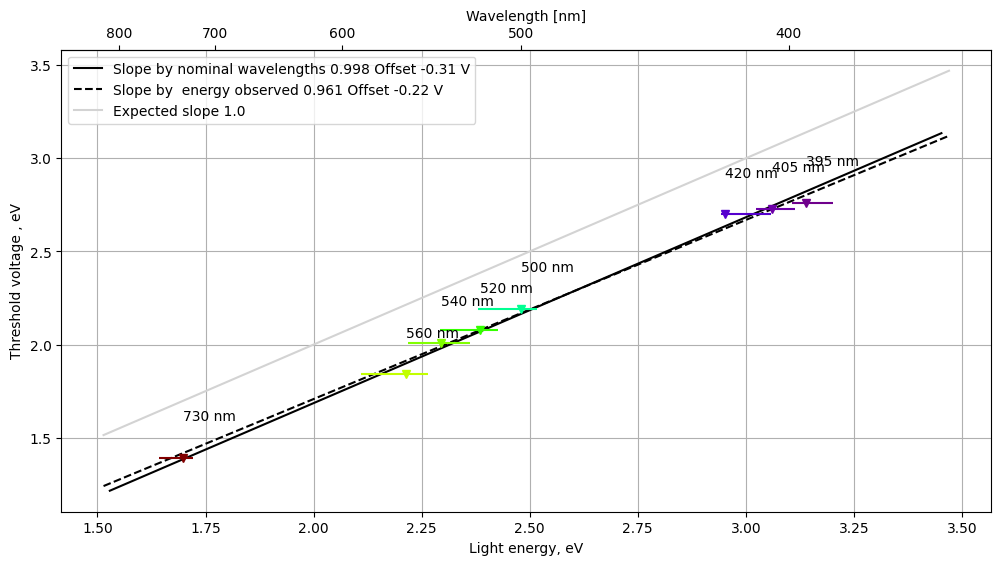

In [76]:
def wl2E(wl):
    return c * h / e / (wl *1e-9)


def E2wl(energy):
    return c * h/ e / energy  * 1e9

fig, ax = plt.subplots(figsize=(12,6))


secax = ax.secondary_xaxis('top', functions=(wl2E, E2wl))
secax.set_xlabel('Wavelength [nm]')


wl_nominal, V0, wl_observed, wl_observed_err = np.genfromtxt(data.splitlines()).T


energy_top = h * c / (wl_observed - wl_observed_err) * 1e9 / e
energy_low = h * c / (wl_observed + wl_observed_err) * 1e9 / e
energy_observed  = h * c / wl_observed * 1e9 / e
energy_err = np.vstack((energy_top - energy_observed, energy_observed - energy_low))

energy_nominal = h * c / wl_nominal * 1e9 / e

energy_for_fit  = energy_nominal
fit = linregress(V0, energy_for_fit)
slope = 1/fit.slope
offset = -fit.intercept / fit.slope
en_dense = np.linspace(np.min(energy_for_fit)*0.9, np.max(energy_for_fit)*1.1)
plt.plot(en_dense, en_dense * slope + offset, color='black',\
         label=rf'Slope by nominal wavelengths {slope:.3f} Offset {offset:.2f} V')

energy_for_fit  = energy_observed
fit = linregress(V0, energy_for_fit)
slope = 1/fit.slope
offset = -fit.intercept / fit.slope
en_dense = np.linspace(np.min(energy_for_fit)*0.9, np.max(energy_for_fit)*1.1)
plt.plot(en_dense, en_dense * slope + offset, color='black', ls='--', \
         label=rf'Slope by  energy observed {slope:.3f} Offset {offset:.2f} V')



for i in range(len(V0)):
  # Reshape energy_err[:, i] from (2,) to (2, 1) for asymmetric errors on a single point
  plt.errorbar(energy_observed[i], V0[i], yerr=0, xerr=energy_err[:, i].reshape((2, 1)), ls='', color=wavelength_to_color(wl_nominal[i]))
  plt.plot( energy_nominal[i], V0[i], marker='v', color=wavelength_to_color(wl_nominal[i]))
  plt.annotate(f'{wl_nominal[i]:.0f} nm', (energy_nominal[i], V0[i]+0.2))

plt.plot(en_dense, en_dense , color='lightgray', label=f'Expected slope 1.0')

#for i in range(len(V0)):
#    plt.annotate(f'{wl[i]*1e9:.0f} nm', (V0[i], energy[i]))

plt.grid()
plt.legend()
plt.xlabel(r'Light energy, eV')
plt.ylabel(r'Threshold voltage , eV')
plt.legend()
plt.show()